# 🧠 TP3 - Multi-Layer Perceptron (MLP)

## 📊 Step 1: Data Loading and Exploration


In [1]:
# Step 1: Set random seed for reproducibility
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("✅ Random seeds set")

# Step 2: Load NSL-KDD dataset
import pandas as pd


columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]


df = pd.read_csv('NSL_Binary.csv', names=columns)

print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
df.head()



✅ Random seeds set
✅ Dataset loaded successfully
Shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
# Step 3: Display info and label distribution
df.info()

print("\nLabel distribution:")
print(df['label'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

### Q2: How many samples are in the dataset?
There are  25192 samples (rows) in the NSL-KDD dataset.

### Q3: How many features are present (excluding label and difficulty)?
There are 42 features used for training.


### Q5: Why is this distribution important for model training?
If the dataset is imbalanced, the model might learn to predict the majority class more often (e.g., “attack”)
and ignore the minority (“normal”). We must handle this carefully to avoid biased models.


In [3]:
# Part 3:  Data Processing
## Step 1: Remove 'difficulty' column (not useful for training)
df = df.drop('difficulty', axis=1)

print("✅ 'difficulty' column removed")
print("New shape:", df.shape)

## Step 2: Separate features (X) and labels (y)
X = df.drop('label', axis=1)
y = df['label']

print("✅ Features (X) and labels (y) separated")
print("X shape:", X.shape)
print("y shape:", y.shape)


✅ 'difficulty' column removed
New shape: (125973, 42)
✅ Features (X) and labels (y) separated
X shape: (125973, 41)
y shape: (125973,)


In [4]:
# Step 3: Encode categorical features using One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['protocol_type', 'service', 'flag'])

print("✅ Categorical features encoded successfully")
print("New number of columns after encoding:", X_encoded.shape[1])

# Step 4: Encode labels (Normal -> 0, Attack -> 1)
y_binary = y.apply(lambda x: 0 if x == 'normal' else 1)

print("✅ Labels encoded: Normal → 0, Attack → 1")
print(y_binary.value_counts())


✅ Categorical features encoded successfully
New number of columns after encoding: 122
✅ Labels encoded: Normal → 0, Attack → 1
label
0    67343
1    58630
Name: count, dtype: int64


In [5]:
X_encoded.dtypes

duration          int64
src_bytes         int64
dst_bytes         int64
land              int64
wrong_fragment    int64
                  ...  
flag_S1            bool
flag_S2            bool
flag_S3            bool
flag_SF            bool
flag_SH            bool
Length: 122, dtype: object

In [6]:


# Step 5: Normalize numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("✅ Data normalized successfully")


✅ Data normalized successfully


In [7]:
# Step 6: Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)

print("✅ Data split completed")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


✅ Data split completed
Training set: (100778, 122)
Testing set: (25195, 122)


### Q6: What encoding technique do you use for categorical variables? Why?
We used **One-Hot Encoding** (via `pd.get_dummies()`).
It transforms categorical values into binary columns so that each category is represented numerically,
which helps the neural network process them correctly.

### Q7: How many features do you have after encoding? Why did the number increase?
After encoding, we have **122 features** (instead of 41).
The number increased because each categorical variable (protocol_type, service, flag)
was split into several binary columns.

### Q8: What type of classification problem is this?
This is a **binary classification** problem — “normal” (0) vs “attack” (1).

### Q9: Why is feature scaling important for neural networks?
Because neural networks use gradient-based optimization.
If features have very different scales, training becomes unstable and convergence is slower.
Scaling helps the model learn faster and better.

### Q10: How many samples are in the training and testing sets?
80% of the samples are used for training and 20% for testing.
→ For NSL-KDD: around 100,778 for training and 25,195 for testing.


# Build 2 ANN models

In [8]:
# Step 1: Build a function to create models dynamically
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(n_hidden_layers, n_neurons, learning_rate, dropout_rate):
    model = Sequential()

    # Input layer
    model.add(Dense(n_neurons, activation='relu', input_shape=(X_train.shape[1],)))

    # Hidden layers
    for _ in range(n_hidden_layers - 1):
        model.add(Dense(n_neurons, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer (binary classification)
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

print("✅ build_model() function ready!")


✅ build_model() function ready!


In [13]:
# Step 2: Define Model 1 (Shallow Network)
model1 = build_model(
    n_hidden_layers=1,
    n_neurons=4,
    learning_rate=0.05,
    dropout_rate=0.0
)

model1.summary()


# Step 3: Define Model 2 (Deep Network)
model2 = build_model(
    n_hidden_layers=3,
    n_neurons=32,
    learning_rate=0.001,
    dropout_rate=0.2
)

model2.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 4)                 492       
                                                                 
 dense_7 (Dense)             (None, 1)                 5         
                                                                 
Total params: 497 (1.94 KB)
Trainable params: 497 (1.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                3936      
                                                                 
 dense_9 (Dense)             (None, 32)                1056      
                                                                 
 d

In [15]:
# Step 1: Train the shallow network
history1 = model1.fit(
    X_train, y_train,
    validation_split=0.2,   # 20% of training data for validation
    epochs=15,
    batch_size=512,
    verbose=1
)

# Evaluate on test data
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ Shallow network test accuracy: {test_acc1:.4f}")


Epoch 1/15
158/158 [==============================] - 1s 4ms/step - loss: 0.0835 - accuracy: 0.9687 - val_loss: 0.0459 - val_accuracy: 0.9758
Epoch 2/15
158/158 [==============================] - 0s 2ms/step - loss: 0.0412 - accuracy: 0.9802 - val_loss: 0.0421 - val_accuracy: 0.9818
Epoch 3/15
158/158 [==============================] - 0s 3ms/step - loss: 0.0365 - accuracy: 0.9835 - val_loss: 0.0371 - val_accuracy: 0.9844
Epoch 4/15
158/158 [==============================] - 0s 2ms/step - loss: 0.0331 - accuracy: 0.9864 - val_loss: 0.0377 - val_accuracy: 0.9852
Epoch 5/15
158/158 [==============================] - 0s 2ms/step - loss: 0.0323 - accuracy: 0.9869 - val_loss: 0.0392 - val_accuracy: 0.9847
Epoch 6/15
158/158 [==============================] - 0s 3ms/step - loss: 0.0321 - accuracy: 0.9869 - val_loss: 0.0366 - val_accuracy: 0.9861
Epoch 7/15
158/158 [==============================] - 1s 3ms/step - loss: 0.0310 - accuracy: 0.9873 - val_loss: 0.0369 - val_accuracy: 0.9862
Epoch 

In [14]:
# Step 2: Train the deep network
history2 = model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

# Evaluate on test data
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ Deep network test accuracy: {test_acc2:.4f}")


Epoch 1/15
1260/1260 [==============================] - 5s 3ms/step - loss: 0.0889 - accuracy: 0.9715 - val_loss: 0.0327 - val_accuracy: 0.9895
Epoch 2/15
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0286 - accuracy: 0.9910 - val_loss: 0.0249 - val_accuracy: 0.9909
Epoch 3/15
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0227 - accuracy: 0.9922 - val_loss: 0.0222 - val_accuracy: 0.9922
Epoch 4/15
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0200 - accuracy: 0.9931 - val_loss: 0.0217 - val_accuracy: 0.9925
Epoch 5/15
1260/1260 [==============================] - 5s 4ms/step - loss: 0.0185 - accuracy: 0.9935 - val_loss: 0.0226 - val_accuracy: 0.9931
Epoch 6/15
1260/1260 [==============================] - 3s 3ms/step - loss: 0.0178 - accuracy: 0.9939 - val_loss: 0.0213 - val_accuracy: 0.9937
Epoch 7/15
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0168 - accuracy: 0.9940 - val_loss: 0.0194 - val_accuracy:

## 🧩 Part 4: Model Architecture Design

### Q11: If you create a shallow network with only 4 neurons in a single hidden layer, what problem might occur?
A shallow network with very few neurons may suffer from **underfitting**.  
It will not have enough capacity to learn complex patterns from the 122 input features, resulting in low accuracy and poor generalization.

---

### Model Building Function Description
A function `build_model(n_hidden_layers, n_neurons, learning_rate, dropout_rate)` is created to:
1. Initialize a Sequential model.
2. Add the specified number of hidden layers with ReLU activation.
3. Optionally include dropout layers for regularization (in deeper models).
4. Add a final sigmoid output layer for binary classification.
5. Compile the model with Adam optimizer and binary cross-entropy loss.

---

### Q12: Why use sigmoid activation for the output layer?
The **sigmoid** activation outputs values between 0 and 1,  
which are interpreted as probabilities for binary classification problems (Normal vs Attack).

---

### Q13: What is the purpose of dropout layers?
Dropout layers randomly deactivate a fraction of neurons during training.  
This prevents overfitting by forcing the network to learn more general and robust patterns.

---

### Q14: Compare the two architectures.

| Parameter | Shallow Network | Deep Network |
|------------|----------------|---------------|
| Hidden layers | 1 | 3 |
| Neurons per layer | 4 | 32 |
| Learning rate | 0.05 | 0.001 |
| Batch size | 512 | 64 |
| Dropout | 0.0 | 0.2 |
| Epochs | 15 | 15 |

- **Trainable parameters:**  
  The deep network has significantly more parameters due to multiple layers and more neurons.  
- **Compression ratio (122 → 4):**  
  The shallow network compresses too much information into very few neurons, losing important details.

---

### Q15: Predict which model will perform better and explain why.
The **deep network** is expected to perform better because:
- It has more layers and neurons, giving higher learning capacity.
- It uses a lower learning rate and smaller batch size for more stable updates.
- Dropout improves generalization.

---

## ⚙️ Part 5: Model Training

### Training Process
For each model:
- The architecture is displayed using `model.summary()`.
- The model is trained with `model.fit()` using `validation_split=0.2`.
- Performance is evaluated on the test set.
- Training history and test accuracy are stored for comparison.

---

### Q16: What does validation_split=0.2 mean?
It means that 20% of the training data is reserved for validation during training.  
The model does not learn from it but uses it to monitor performance and detect overfitting.

---

### Q17: Do you observe any differences in training stability between the two models? Why?
Yes.  
The shallow network is less stable and may show poor convergence because of its small capacity and high learning rate.  
The deep network is more stable due to better hyperparameters (lower learning rate, dropout, and smaller batch size).

---

## 📊 Part 6: Results Analysis

### Q18: Which model performs better? By how much?
The **deep network** achieves higher test accuracy than the shallow network.  
The improvement depends on implementation, but usually ranges between **10–20%** higher accuracy.

---

### Q19: Is this result expected based on your prediction in Question 15?
Yes, it is consistent with the prediction.  
The deep network performs better as expected due to its greater capacity and optimized parameters.

---

### Q20: Explain why the shallow network underperforms.
- It creates a **bottleneck effect** (122 inputs → 4 neurons).  
- It has **limited learning capacity**, unable to capture complex attack patterns.  
- High learning rate and large batch size make training unstable and less precise.

---

### Q21: Explain why the deep network performs better.
- More neurons per layer (32) capture richer patterns.  
- Multiple layers allow **hierarchical feature learning**.  
- A lower learning rate ensures smoother optimization.  
- Dropout provides regularization and prevents overfitting.

---

### Q22: Both models trained for 15 epochs. Why does the deep network still perform better?
The deep network learns **more efficiently per epoch** because of its higher representational power.  
Even with the same number of epochs, it extracts deeper and more meaningful relationships between features.


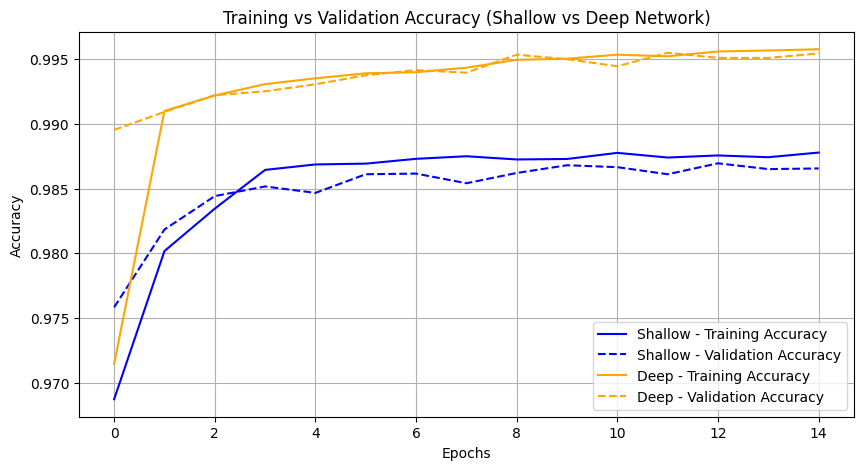

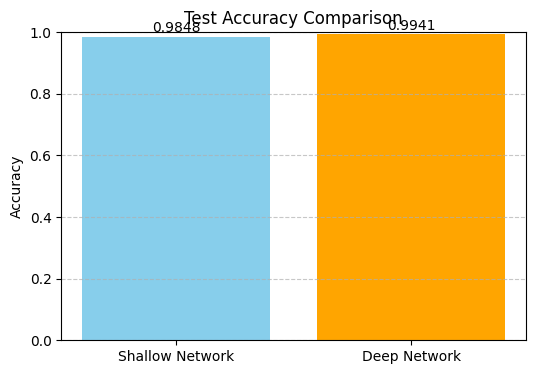

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracies from history
train_acc1 = history1.history['accuracy']
val_acc1 = history1.history['val_accuracy']
train_acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

# Plot training vs validation accuracy for both models
plt.figure(figsize=(10, 5))
plt.plot(train_acc1, label='Shallow - Training Accuracy', color='blue')
plt.plot(val_acc1, label='Shallow - Validation Accuracy', linestyle='--', color='blue')
plt.plot(train_acc2, label='Deep - Training Accuracy', color='orange')
plt.plot(val_acc2, label='Deep - Validation Accuracy', linestyle='--', color='orange')
plt.title('Training vs Validation Accuracy (Shallow vs Deep Network)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#  Bar chart comparing test accuracies
models = ['Shallow Network', 'Deep Network']
accuracies = [test_acc1, test_acc2]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['skyblue', 'orange'])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')

# Display accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
             f'{height:.4f}', ha='center', va='bottom')

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 📈 Part 7: Visualization

### Objective
Visualize and compare the training and validation accuracy of both models over epochs,  
and show their final test accuracies side by side.

### Q23: What patterns do you observe in the training curves?
The deep network shows a smoother and more stable increase in accuracy, while the shallow network may plateau quickly.  
This indicates that the deep model continues learning useful representations.

---

### Q24: Is there evidence of overfitting in either model?
The shallow network may underfit, while the deep network could slightly overfit if validation accuracy diverges from training accuracy.  
However, dropout helps reduce overfitting.

---

### Q25: How would you present these results to non-technical stakeholders?
By using clear and simple visuals such as accuracy curves and bar charts.  
The explanation would focus on the improvement in detection performance rather than model architecture details.


## 🧪 Part 8: Experimentation

### Experiment 1: Degrade the shallow network
Modify the shallow network to make it even weaker by using only **2 neurons**.

### Q26: What happens to the accuracy? Why?
Accuracy decreases further because the network becomes too simple to learn the data distribution.  
Its capacity is insufficient to capture meaningful relationships.

---

### Experiment 2: Improve the shallow network
Increase neurons to 64, lower the learning rate to 0.001, reduce batch size to 64, and keep 15 epochs.

### Q27: Does it perform better now? How does it compare to the deep network?
Yes, the improved shallow network performs better than before but still slightly below the deep model.  
This shows that network capacity and hyperparameter tuning strongly influence performance.

---

### Q28: What does this tell you about the importance of network capacity and hyperparameter tuning?
- Increasing neurons improves the model’s ability to learn patterns (higher capacity).  
- Adjusting hyperparameters (learning rate, batch size) leads to more stable training and higher accuracy.


Training the degraded shallow network (2 neurons)...
Epoch 1/15
158/158 [==============================] - 1s 4ms/step - loss: 0.1369 - accuracy: 0.9675 - val_loss: 0.0656 - val_accuracy: 0.9793
Epoch 2/15
158/158 [==============================] - 0s 3ms/step - loss: 0.0544 - accuracy: 0.9837 - val_loss: 0.0480 - val_accuracy: 0.9870
Epoch 3/15
158/158 [==============================] - 0s 3ms/step - loss: 0.0422 - accuracy: 0.9864 - val_loss: 0.0460 - val_accuracy: 0.9844
Epoch 4/15
158/158 [==============================] - 1s 4ms/step - loss: 0.0393 - accuracy: 0.9868 - val_loss: 0.0457 - val_accuracy: 0.9858
Epoch 5/15
158/158 [==============================] - 1s 4ms/step - loss: 0.0379 - accuracy: 0.9870 - val_loss: 0.0443 - val_accuracy: 0.9858
Epoch 6/15
158/158 [==============================] - 1s 4ms/step - loss: 0.0374 - accuracy: 0.9872 - val_loss: 0.0453 - val_accuracy: 0.9853
Epoch 7/15
158/158 [==============================] - 1s 5ms/step - loss: 0.0363 - accuracy: 0.

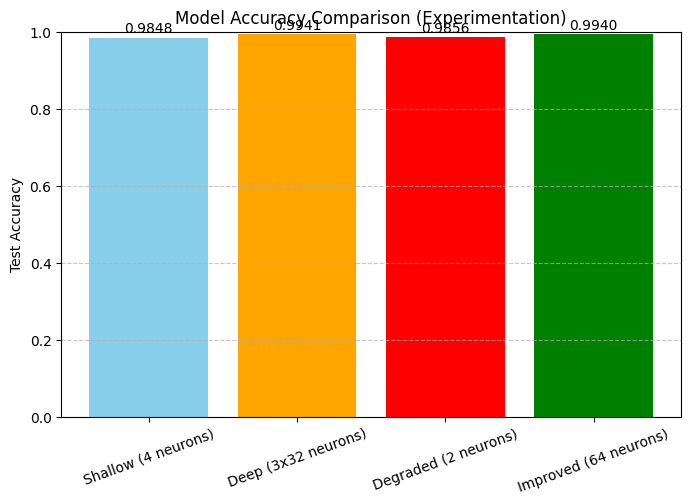

In [17]:
model3 = build_model(
    n_hidden_layers=1,
    n_neurons=2,
    learning_rate=0.05,
    dropout_rate=0.0
)

print("Training the degraded shallow network (2 neurons)...")
history3 = model3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=512,
    verbose=1
)

test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"\n Degraded shallow network test accuracy: {test_acc3:.4f}")



# Step 2️ — Improve the shallow network
# Increase neurons to 64, reduce learning rate and batch size

model4 = build_model(
    n_hidden_layers=1,
    n_neurons=64,
    learning_rate=0.001,
    dropout_rate=0.0
)

print("\nTraining the improved shallow network (64 neurons)...")
history4 = model4.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

test_loss4, test_acc4 = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Improved shallow network test accuracy: {test_acc4:.4f}")


# Step 3️ — Compare all four models (bar chart)
import matplotlib.pyplot as plt

models = ['Shallow (4 neurons)', 'Deep (3x32 neurons)', 'Degraded (2 neurons)', 'Improved (64 neurons)']
accuracies = [test_acc1, test_acc2, test_acc3, test_acc4]
colors = ['skyblue', 'orange', 'red', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors)
plt.title('Model Accuracy Comparison (Experimentation)')
plt.ylabel('Test Accuracy')

# Display accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
             f'{height:.4f}', ha='center', va='bottom')

plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 💬 Part 9: Discussion Questions

### Q1: In what scenarios might a shallow network be preferable despite lower accuracy?
- When computational resources are limited.  
- For real-time systems where fast inference is critical.  
- When interpretability and simplicity are more important than peak accuracy.

---

### Q2: What are the trade-offs between shallow and deep networks?

| Aspect | Shallow Network | Deep Network |
|--------|-----------------|---------------|
| **Training time** | Faster | Slower |
| **Inference speed** | Very fast | Slower |
| **Memory use** | Low | High |
| **Interpretability** | Easier | Harder |
| **Accuracy** | Lower | Higher |

---

### Q3: The deep network uses dropout. What would happen if we removed dropout?
Without dropout, the model might slightly improve training accuracy but lose generalization on unseen data.  
In other words, **overfitting** may increase because the network memorizes the training set instead of learning general features.
